# Exploratory Data Analysis

## Outline

- Random Variable: A phenomenon whose outcome is not yet known
- Statistics, Machine Learning: Guessing future values of a phenomenon, based on past observations
- Exploratory Data Analysis: Discovering basic features of variables

1. Analyze categorical/numeric variables: Mean/standard deviation, median/IQR, 
2. Analyze pairs of categorical/numeric variables

# 1. Single Variables

## Recall: Getting to Know a Variable
- Current data type, `df[var].dtype`
- Number of missings, `df[var].isna().sum()`
- Unique values it takes, `df[var].unique()`
- Counts associated with unique values, `df[var].value_counts()`
- Histogram of the value counts, `df[var].hist( bins = 35 )`

> From this, you should be able to decide whether the variable is clean enough to proceed; otherwise, go back and clean it again

In [2]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('airbnb.csv',low_memory=False)
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [4]:
df.dtypes


Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object

<Axes: xlabel='Review Scores Rating'>

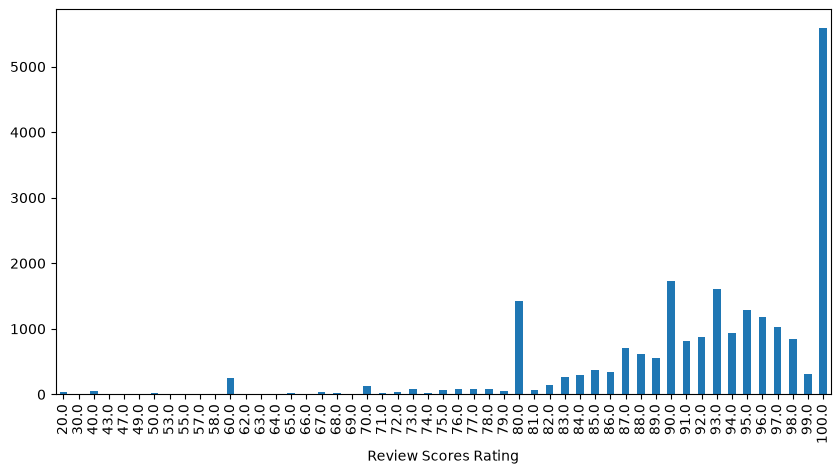

In [3]:
df['Review Scores Rating'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5))

In [ ]:
df["review_missing"] = df['Review Scores Rating'].isna()
df["Review Scores Rating"] = df

In [ ]:
pd.to_numeric(df['Price'].str.replace(",","")), (errors = 'coerce')

SyntaxError: unmatched ')' (2188198608.py, line 1)

## Statistics
- A **statistic** is a function that maps data into a number
    - Proportion: What proportion of observations take a particular label?
    - Mean: What is the average of the recorded values of the variable?

In [10]:
df['Property Type'].value_counts().hist

<bound method hist_series of Property Type
Apartment          27102
House               2090
Loft                 753
Bed & Breakfast      180
Townhouse            136
Condominium           94
Other                 47
Dorm                  31
Boat                   8
Villa                  8
Camper/RV              7
Bungalow               4
Treehouse              4
Tent                   4
Hut                    2
Cabin                  2
Lighthouse             1
Chalet                 1
Castle                 1
Name: count, dtype: int64>

## Analyzing a Categorical
- Analyzing a categorical variable $C$ is about computing how often it takes each possible label $\ell$: How are the data spread out across labels?

- A **sample proportion** is the fraction of observations taking the value $\ell$

- Proportions of labels, among non-missing values: 
    - `df[var].value_counts(normalize=True)`
- Proportions of labels, including missing values as an additional category: 
    - `df[var].value_counts(normalize=True, dropna=False)`

- Bar/count plot for visualization: 
    - `sns.countplot(x=df[var],stat='proportion')`
    - `sns.countplot(data=df, x=var, stat='proportion')`

## Analyzing a Numeric

- Analyzing a numeric variable $x$ is about computing how of: How are the data spread out across numeric values?
- To visualize the variable, `sns.histplot( df[var], bins=50)`
- For basic numeric summary, `df[var].describe()`


## Mean and Variance

- How disperse is your variable, $X = (x_1, ... , x_n)$?
- The **sample mean** is a standard measure of central tendency, the arithmetic average of the data:
$$
M(X) = \dfrac{x_1 + x_2 + ... + x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i
$$
- The **sample variance** is the arithmetic average of sum of squares of the observations from the mean,
$$
V(X) = \dfrac{1}{n} \sum_{i=1}^n (x_i - M(X))^2
$$
- The **sample standard deviation** is the square root of sample variance: $\text{sd}(x) = \sqrt{V(X)}$

## Median

- The mean and variance are particular sensitive to **outliers**: Values that are atypically high or low, and exert a lot of leverage on $M(X)$ and $V(X)$
- **Robust statistics** is the study of estimators that are less sensitive to outlier
- The **sample median** is a robust measure of central tendency, and corresponds to the value of $X$ for which half the data are above it, and half the data are below it:

$$\mathrm{med}(x) = \begin{cases}
x_{\left(\frac{n+1}{2}\right)} & n \text{ odd} \\[4pt]
\tfrac{1}{2}\left(x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}\right) & n \text{ even}
\end{cases}$$

- `df['var'].med()`

## Quantiles

- The median targets "this is the value for which half of the sample is below, and half of the sample is above"
- What if said, "I want to find the value for which a proportion $f$ of the sample is below, and $(1-f)%$ of the sample is above"
- This is called the **$f$-th quantile**:
  
$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}, \qquad \hat q_f = x_{(\lceil n f \rceil)}$$

- `np.quantile(X,f)`

In [ ]:
#Median and Interquartile are robust to outliers

from math import cell
#70th percentile

def quantile (x, frac):


## Two Useful Transformations
- Almost every dataset I have ever opened has a few data with **long tails**: The mean is much larger or smaller than the median, because the data have a very small number of very large values
- To visualize and numerically stabilize these kinds of variables, we often take the **natural logarithm**, `df['var_ln'] = np.log(df[var])`
    - The natural log has two problems: At zero it goes to $-\infty$ and it is not defined for negative numbers
- The better choice is called the **inverse hyperbolic sine** or **arcinsh**, `df['var_ihs'] = np.arcsinh(df[var])`:
$$
i(x) = \ln \left( x + \sqrt{x^2+1} \right) 
$$
- This is defined for positive and negative values and takes the value zero at zero


# 2. Pairs of Variables

## Pairs of Categoricals

- To break out counts by two categoricals at the same time, we use a **contingency table** or **cross-tabulation**: `pd.crosstab(df[var1], df[var2])`
- This provides the joint counts for two categorical variables, allowing us to see how they vary together or not

## Pairs of Numerics

- How do we visualize the relationship between two variables?
- The numeric version of a contingency table is a scatterplot: `sns.scatterplot( x = df[var1], y=df[var2], alpha = .15 )`
- We often want to summarize that picture with a number, and typically use
$$
\text{cov}(X,Y) = \frac{\sum_{i=1}^n (x_i - M(X))(y_i - M(Y))}{n}
$$

- This can easily be computed: `df[[var1, var2]].cov()`

## Numeric by Categorical

- To **conditional** analysis of a numeric variable `num` on a categorical variable `cat`, we perform an analysis on subgroups of the data determined by their labelling
- To visualize a numeric conditional on a categorical, you can use `hue`: `sns.kdeplot( x = df[num], hue = df[cat], fill=True)`

## Group By
- A general description by groups: 
    - `df[[cat,num]].groupby(cat).describe()`
- Specific statistics: `df[[cat,num]].groupby(cat).count()` or `.mean()`, `.sum()`, `.count()`, etc.
- For a custom function, `fcn()`: `df[[cat,num]].groupby(cat).agg(fcn)`
- If you are analyzing the top or bottom of a set of observations, it often makes sense to use `.sort()` at the end